# Neural Networks as Function Approximators


We will treat Neural Networks(NN) as a mathematical function that learns its own parameters from data. So it will be our flexible "Black Box":

**Input:** State/Image (vector of numbers)

**Black Box:** A series of matrix multiplications (weights) and filters (activations).

**Output:** Prediction (vector of probabilities).

Our goal is to tune the "knobs" (weights) of this black box so that the outputs match reality.

## Pipeline (Model Centric)

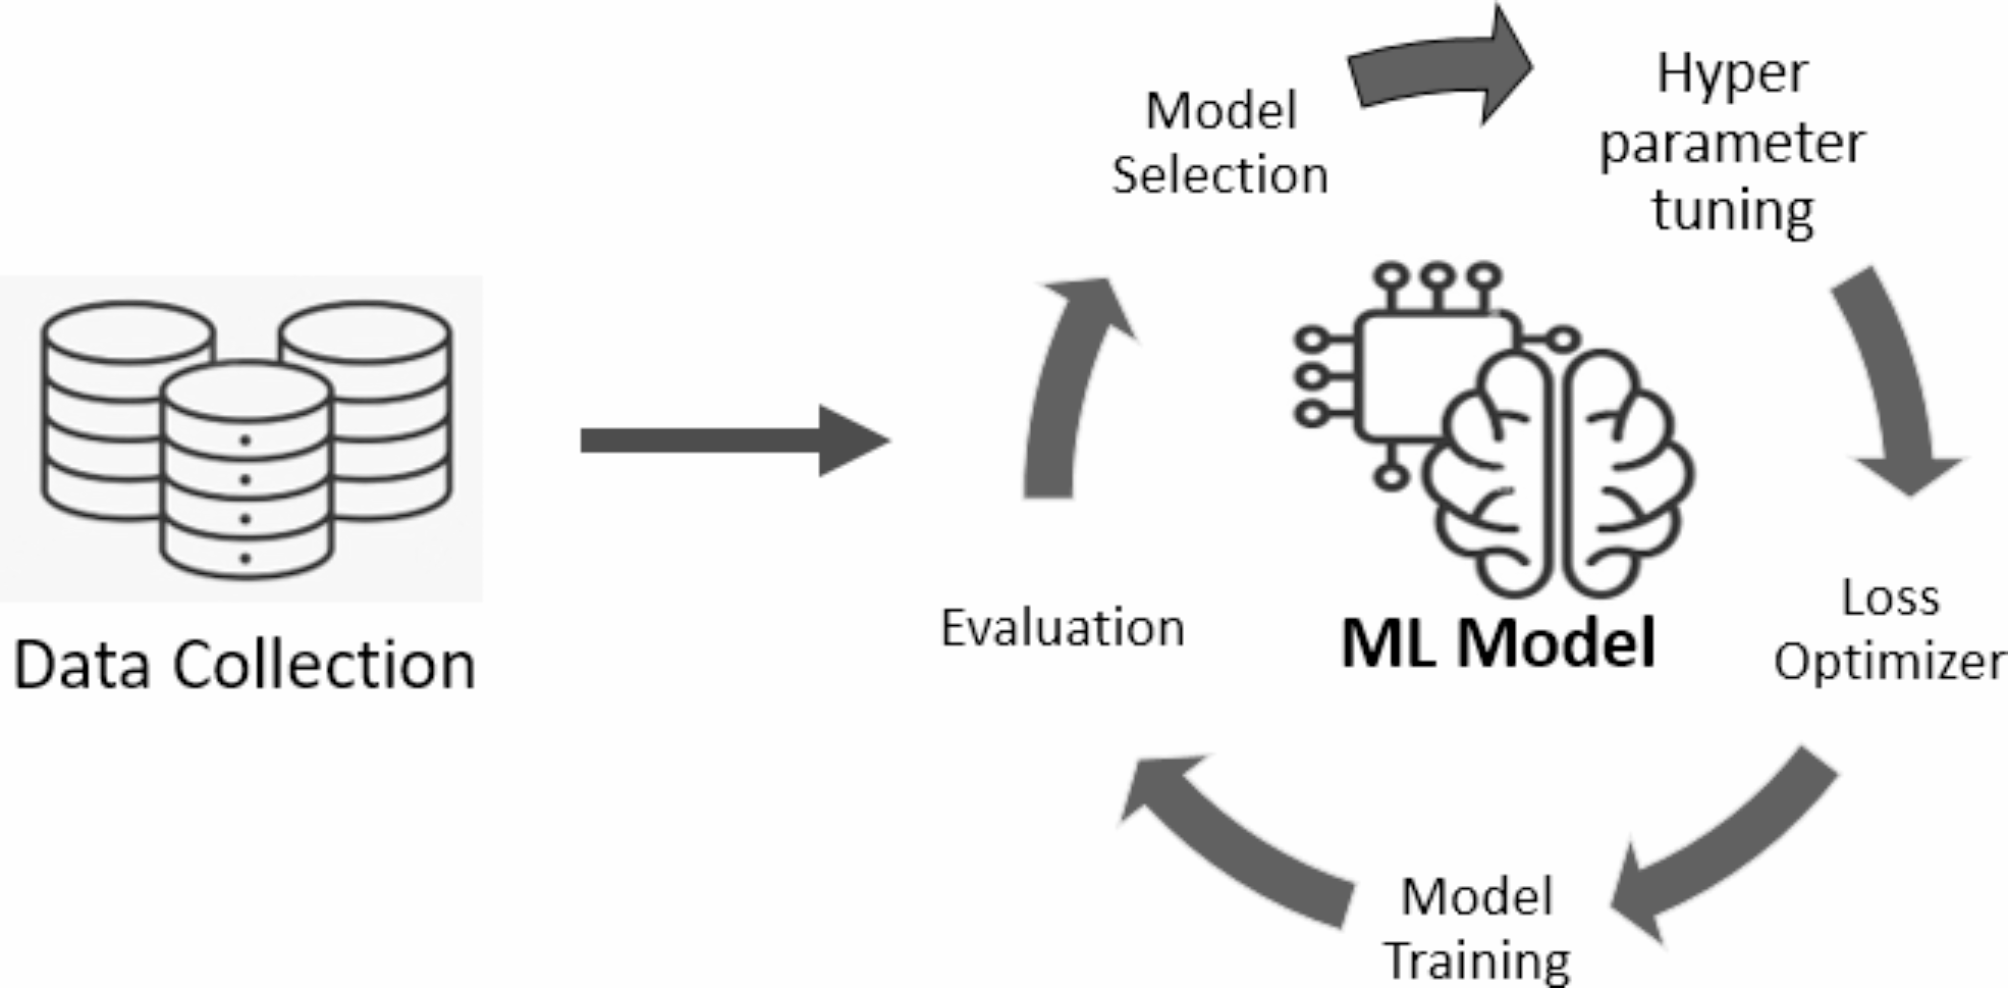

## The Dataset (Fashion MNIST)

We will use Fashion MNIST. Unlike the classic handwritten digits, this dataset represents a more complex pattern recognition task: classifying clothing items (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot).

**Input**: $28 \times 28$ grayscale images.

**Output**: One of 10 classes.

**Loading and Visualizing Data**



In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Configuration
BATCH_SIZE = 64

# 1. Prepare Data Loaders
# Transform converts images (0-255) to Tensors (0.0-1.0) and normalizes them
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# 2. Define Class Names
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# 3. Visualize a Batch
def imshow(img):
    img = img / 2 + 0.5  # unnormalize for display
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.show()

# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
print("Sample Batch of Data:")
imshow(torchvision.utils.make_grid(images[:8])) # Show first 8
print(' '.join(f'{classes[labels[j]]:10s}' for j in range(8)))

As we have the input and labels for each data peace, this dataset is good for **Supervised Learning**.

## The Model
We will define our model as a very simple neural network - Multi-Layer Perceptron (MLP). As the name suggests it consists of multiple layers with neurons. We simply flatten the image to a vector of numbers.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # 1. Input to Hidden Layer
        # We map 784 pixels to 128 hidden "neurons"
        self.fc1 = nn.Linear(28 * 28, 128)

        # 2. Hidden to Output Layer
        # We map 128 hidden neurons to 10 class scores
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # x shape: [batch_size, 1, 28, 28]

        # Step 1: Flatten the image
        x = x.view(-1, 28 * 28)

        # Step 2: First Layer + Activation
        x = F.relu(self.fc1(x))

        # Step 3: Output Layer (Raw Scores / Logits)
        x = self.fc2(x)
        return x

# Initialize the model
model = SimpleNN()
print(model)

## The Objective (Loss Function)

So far, we have defined data and the model. Now, we need to make the model learn and update it's weights based on the data. In Supervised Learning, we update weights based on the "Error" or Loss.

There are many loss functions used in the Neural Network training. However, the one we need a function that compares:
* Prediction: The network's guess (e.g., 90% chance it's a T-shirt).
* Truth: The actual label (It is a T-shirt).

For that purpose the Cross-Entropy Loss will work great. It minimizes the error heavily if the model is confident but wrong.



$$Loss = - ∑_{i\in \text{samples ids}} y_i ⋅ ln(\hat{y_i})$$

**Exercise:** Understanding the Loss

Instead of using the library function immediately, let's implement the logic to understand what we are optimizing.
$$Loss = - \ln(\text{probability of the correct class})$$

**Question:**
1. What is the loss value when the model predicts $1.0$ (100%) for the correct class?
2. What is the loss value when the model predicts $0.01$ (1%) for the correct class?



In [ ]:

def manual_cross_entropy(logits, targets):
    """
    logits: Raw scores from the model. Shape: [Batch_Size, 10]
    targets: Correct class indices. Shape: [Batch_Size]
    """
    # 1. Turn raw scores into probabilities (0 to 1) using Softmax
    # Formula: e^x / sum(e^x)
    probabilities = F.softmax(logits, dim=1)

    # 2. Select the probability corresponding to the correct class for each image
    # We use 'targets' as indices to pick the right probability (otherwise, for other classes the loss will be 0)
    batch_size = logits.shape[0]
    correct_probs = probabilities[range(batch_size), targets]

    # 3. Calculate Negative Log Likelihood
    # TODO: Implement the formula

    loss = ...

    # Return average over the batch
    return torch.mean(loss)


# Quick Test
dummy_out = torch.tensor([[2.0, 1.0, 0.1], [0.5, 2.0, 0.3]]) # 2 images, 3 classes
dummy_target = torch.tensor([0, 1]) # Correct classes
print(f"Manual Loss: {manual_cross_entropy(dummy_out, dummy_target):.4f}")

## Optimization
Now we need an algorithm to change the weights to minimize our loss. We will use SGD (Stochastic Gradient Descent), you don't need to worry what it does exactly. Just think of it as an optimization algorithm which updates the model based on the loss.


In [ ]:
import torch.optim as optim

# We use the built-in CrossEntropyLoss for numerical stability in the actual loop
criterion = nn.CrossEntropyLoss()

# The Optimizer holds the model's parameters and updates them
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

## The Training Loop
This is the core of the learning process. In each step, we:

1. Forward: Pass data through the Model.

2. Loss: Calculate how good/bad the prediction was.

3. Backward: Calculate gradients (direction to move the weights).

4. Step: Update the weights.

In [ ]:
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    loss_history = []

    for epoch in range(epochs):  # Loop over the dataset multiple times
        running_loss = 0.0

        for i, data in enumerate(train_loader, 0):
            inputs, labels = data

            # --- OPTIMIZATION STEP ---

            # 1. Zero the parameter gradients (clear history)
            optimizer.zero_grad()

            # 2. Forward Pass
            outputs = model(inputs)

            # 3. Compute Loss
            loss = criterion(outputs, labels)

            # 4. Backward Pass (Calculate Gradients)
            loss.backward()

            # 5. Optimize (Update Weights)
            optimizer.step()

            # --- LOGGING ---
            running_loss += loss.item()
            if i % 100 == 99:    # Print every 100 steps
                avg_loss = running_loss / 100
                print(f'[Epoch {epoch + 1}, Step {i + 1}] loss: {avg_loss:.3f}')
                loss_history.append(avg_loss)
                running_loss = 0.0

    print('Finished Training')
    return loss_history

# Run the training
history = train_model(model, train_loader, criterion, optimizer, epochs=5)

**Question:**

Based on above code explain what is
*   step
*   epoch
*   batch

Where is the loss calculated? Where do we update our weights?



**Visualize Learning**

In [ ]:
plt.plot(history)
plt.title('Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.show()

**Question:**

Did the model learn the pattern? Why yes or why not?



## Evaluation
The model has learned from the training data. Now, let's see how it performs on unseen data (the Test Set). This checks if the model actually learned the concepts (e.g., shape of a shoe) or just memorized the training images.

**Qualitative Check**
Let's look into the specific images and see if the model guessed correctly

In [ ]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images[:8]))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:10s}' for j in range(8)))

# Get Model Predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

print('Predicted:   ', ' '.join(f'{classes[predicted[j]]:10s}' for j in range(8)))

**Quantitative Check (Accuracy)**

In [ ]:
correct = 0
total = 0

# No gradient needed for evaluation
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = model(images)

        # The class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10,000 test images: {100 * correct / total:.2f} %')

**Accuracy per class**

Let's now see how good our model is in classifying each class. We will look into the true positives, true negatives, false positives and false negatives.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Per-class TP, FP, FN, TN
print(f'{"Class":>15s} | {"TP":>5s} {"FP":>5s} {"FN":>5s} {"TN":>5s} | {"Accuracy":>8s}')
print('-' * 60)
for i, cls_name in enumerate(classes):
    tp = int(((all_preds == i) & (all_labels == i)).sum())
    fp = int(((all_preds == i) & (all_labels != i)).sum())
    fn = int(((all_preds != i) & (all_labels == i)).sum())
    tn = int(((all_preds != i) & (all_labels != i)).sum())
    acc = (tp + tn) / (tp + fp + fn + tn)
    print(f'{cls_name:>15s} | {tp:5d} {fp:5d} {fn:5d} {tn:5d} | {acc:8.2%}')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


## [Optional] Misclasification penalization
Let's say that we are in a serious fashion buisness, we make elegant clothes. And specifically, we can't let our Shirts be misclassified as non-elegant T-shirts because it would harm our image. Can we design a loss function that would help with this issue?

**Weighted Cross-Entropy Loss**

The idea is simple: we assign a higher weight to the class we care about. When the model misclassifies that class, the loss is multiplied by a larger number, so the gradient is stronger and the model is pushed harder to get that class right.


$$Loss = - ∑_{i\in \text{samples ids}} w_{y_i} \cdot y_i ⋅  ln(\hat{y_i})$$

where $w_{y_i}$ is the weight for the true class of sample $i$. For most classes we keep $w = 1.0$, but for our important class we set $w > 1$.


In [ ]:
# Pick the classes we want to protect
IMPORTANT_CLASSES = [6]  # 'Shirt' — change to any class indices (0-9)
IMPORTANT_WEIGHT = 5.0  # How much more we penalize misclassifying these classes

# Build a weight vector: 1.0 for every class, except our important ones
class_weights = torch.ones(10)
for idx in IMPORTANT_CLASSES:
    class_weights[idx] = IMPORTANT_WEIGHT
names = ', '.join(f'"{classes[idx]}"' for idx in IMPORTANT_CLASSES)
print(f'Class weights: {class_weights.tolist()}')
print(f'Penalizing misclassification of {names} {IMPORTANT_WEIGHT}x more.\n')

# Create the weighted loss function
weighted_criterion = nn.CrossEntropyLoss(weight=class_weights)

# Re-initialize a fresh model and optimizer so we start from scratch
model_weighted = SimpleNN()
optimizer_weighted = optim.SGD(model_weighted.parameters(), lr=0.01, momentum=0.9)

# Train with the weighted loss
history_weighted = train_model(model_weighted, train_loader, weighted_criterion, optimizer_weighted, epochs=5)


Let's see the results now!

In [ ]:
# --- Overall accuracy ---
correct = 0
total = 0
all_preds_w = []
all_labels_w = []

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = model_weighted(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds_w.extend(predicted.numpy())
        all_labels_w.extend(labels.numpy())

print(f'Overall accuracy (weighted model): {100 * correct / total:.2f} %\n')

all_preds_w = np.array(all_preds_w)
all_labels_w = np.array(all_labels_w)

# --- Per-class comparison ---
print(f'{"Class":>15s} | {"Baseline":>8s} {"Weighted":>8s} | {"Diff":>6s}')
print('-' * 55)
for i, cls_name in enumerate(classes):
    # Baseline per-class accuracy (recall)
    mask_base = (all_labels == i)
    acc_base = (all_preds[mask_base] == i).sum() / mask_base.sum()
    # Weighted per-class accuracy (recall)
    mask_w = (all_labels_w == i)
    acc_w = (all_preds_w[mask_w] == i).sum() / mask_w.sum()
    diff = acc_w - acc_base
    marker = ' ◀' if i in IMPORTANT_CLASSES else ''
    print(f'{cls_name:>15s} | {acc_base:8.2%} {acc_w:8.2%} | {diff:+6.2%}{marker}')

# --- Confusion matrix for weighted model ---
cm_w = confusion_matrix(all_labels_w, all_preds_w)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(ax=axes[0], xticks_rotation=45, cmap='Blues')
axes[0].set_title('Baseline Model')

ConfusionMatrixDisplay(confusion_matrix=cm_w, display_labels=classes).plot(ax=axes[1], xticks_rotation=45, cmap='Oranges')
axes[1].set_title('Weighted Loss Model')

plt.tight_layout()
plt.show()


**Question**

Looking at the accuracy results and confusion matrix for both losses:


*   How did the accuracy for Shirts change? What about the false positives? Why?
*   How other classes accuracies change? Why?
*   What could we do to improve the results?



**Excercise**

Play with the loss function, you can change the parameters in the weighted cross entropy or design your own.